   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 1.8 MB/s eta 0:00:00
--- ՔԱՅԼ 1. ՎԵՐԲԵՌՆԵՔ ՍՈՎՈՐԵԼՈՒ ՖԱՅԼԵՐԸ ---


Saving ԱԿՍԵԼ ԲԱԿՈՒՆՑ ԿԱՐՄՐԱՔԱՐ.docx to ԱԿՍԵԼ ԲԱԿՈՒՆՑ ԿԱՐՄՐԱՔԱՐ.docx
Saving ԵՂԻՇԵ ՉԱՐԵՆՑ ԵՐԿԻՐ ՆԱԻՐԻ ԱԲ.docx to ԵՂԻՇԵ ՉԱՐԵՆՑ ԵՐԿԻՐ ՆԱԻՐԻ ԱԲ.docx
Saving ԽԱՉԱՏՈՒՐ ԱԲՈՎՅԱՆ ՎԵՐՔ ՀԱՅԱՍՏԱՆԻ ԳԼՈՒԽ 1.docx to ԽԱՉԱՏՈՒՐ ԱԲՈՎՅԱՆ ՎԵՐՔ ՀԱՅԱՍՏԱՆԻ ԳԼՈՒԽ 1.docx
Saving ՄՈՒՐԱՑԱՆ ԳևՈՐԳ ՄԱՐԶՊԵՏՈՒՆԻ Ա-Է.docx to ՄՈՒՐԱՑԱՆ ԳևՈՐԳ ՄԱՐԶՊԵՏՈՒՆԻ Ա-Է.docx
Saving ՇԻՐՎԱՆԶԱԴԵ ՉԱՐ ՈԳԻ 1-10.docx to ՇԻՐՎԱՆԶԱԴԵ ՉԱՐ ՈԳԻ 1-10.docx
Saving ՐԱՖՖԻ ԽԵՆԹԸ ՄԻՆՉև ԺԷ.docx to ՐԱՖՖԻ ԽԵՆԹԸ ՄԻՆՉև ԺԷ.docx

--- ՔԱՅԼ 2. ՎԵՐԲԵՌՆԵՔ ԲՈԼՈՐ ՍՏՈՒԳՎՈՂ ՖԱՅԼԵՐԸ ---


Saving Ալինա 1-6.docx to Ալինա 1-6.docx
Saving Առաջին սերը.docx to Առաջին սերը.docx
Saving Երևանի ուղղիչ տնից 2-6.docx to Երևանի ուղղիչ տնից 2-6.docx
Saving Խաչագողի հիշատակարանը Ա.docx to Խաչագողի հիշատակարանը Ա.docx
Saving Կյորես.docx to Կյորես.docx
Saving Նոյի ագռավ.docx to Նոյի ագռավ.docx


,Ֆայլ,Բակունց,Չարենց,Աբովյան,Մուրացան,Շիրվանզադե,Րաֆֆի,Կանխատեսում
0,Ալինա 1-6.docx,-2.558457,-2.537694,-2.720905,-2.543642,-2.529366,-2.535868,Շիրվանզադե
1,Առաջին սերը.docx,-2.599988,-2.653263,-2.492759,-2.777758,-2.721660,-2.728012,Աբովյան
2,Երևանի ուղղիչ տնից 2-6.docx,-2.543934,-2.526490,-2.693460,-2.570607,-2.571581,-2.549597,Չարենց
3,Խաչագողի հիշատակարանը Ա.docx,-2.489338,-2.485029,-2.610833,-2.496305,-2.479474,-2.445717,Րաֆֆի
4,Կյորես.docx,-2.518937,-2.542193,-2.674529,-2.620542,-2.565893,-2.548479,Բակունց
5,Նոյի ագռավ.docx,-2.517679,-2.488009,-2.677198,-2.492991,-2.514572,-2.478725,Րաֆֆի


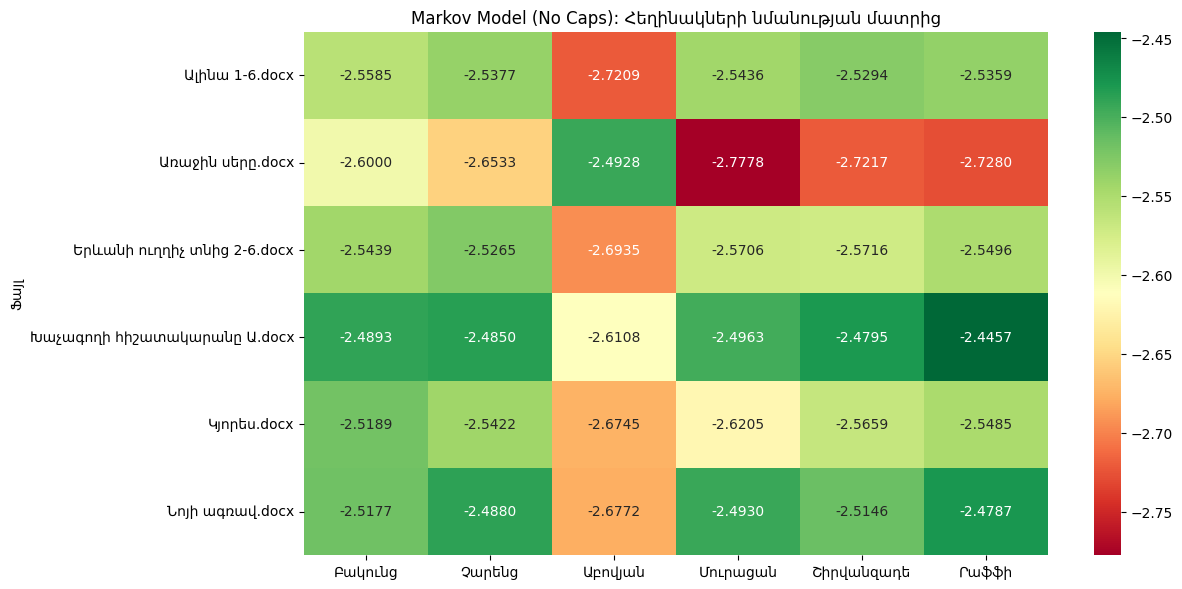

In [1]:
import math
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

!pip install python-docx
from docx import Document

alphabet = ' աբգդեզէըթժիլխծկհձղճմյնշոչպջռսվտրցւփքևօֆ'
n, alpha = len(alphabet), 1e-4
authors_to_find = ["Աբովյան", "Րաֆֆի", "Բակունց", "Շիրվանզադե", "Չարենց", "Մուրացան"]

def read_docx(filename):
    return " ".join([p.text for p in Document(filename).paragraphs])

def text_processing(text):
    # Հեռացվել է .lower(): Մեծատառերը պարզապես դուրս կմնան 'if x in alphabet' պայմանի պատճառով
    tx = text.replace("ու", "ւ")
    clean = ''.join([x for x in tx if x in alphabet])
    return " " + " ".join(clean.split()) + " "

def transition_matrix(text):
    pair, row_sums = [[0]*n for _ in range(n)], [0]*n
    for k in range(len(text)-1):
        idx1, idx2 = alphabet.index(text[k]), alphabet.index(text[k+1])
        pair[idx1][idx2] += 1
        row_sums[idx1] += 1
    return [[(pair[i][j] + alpha) / (row_sums[i] + alpha * n) for j in range(n)] for i in range(n)]

def markov_score(test_text, model_P):
    if len(test_text) < 2: return -1e10
    log_L = 0
    for k in range(len(test_text)-1):
        idx1, idx2 = alphabet.index(test_text[k]), alphabet.index(test_text[k+1])
        log_L += math.log(model_P[idx1][idx2])
    return log_L / (len(test_text)-1)

# 1. ՍՈՎՈՐԵԼՈՒ ՓՈՒԼ
print("--- ՔԱՅԼ 1. ՎԵՐԲԵՌՆԵՔ ՍՈՎՈՐԵԼՈՒ ՖԱՅԼԵՐԸ ---")
uploaded_train = files.upload()
author_files = {auth: fname for fname in uploaded_train.keys() for auth in authors_to_find if auth.lower() in fname.lower()}
markov_models = {name: transition_matrix(text_processing(read_docx(fname))) for name, fname in author_files.items()}

# 2. ԹԵՍՏԱՎՈՐՄԱՆ ՓՈՒԼ
print("\n--- ՔԱՅԼ 2. ՎԵՐԲԵՌՆԵՔ ԲՈԼՈՐ ՍՏՈՒԳՎՈՂ ՖԱՅԼԵՐԸ ---")
uploaded_tests = files.upload()
all_results = []

for test_filename in uploaded_tests.keys():
    test_text = text_processing(read_docx(test_filename))
    res_row = {'Ֆայլ': test_filename}
    for name, P in markov_models.items():
        res_row[name] = markov_score(test_text, P)
    scores_only = {k: v for k, v in res_row.items() if k != 'Ֆայլ'}
    res_row['Կանխատեսում'] = max(scores_only, key=scores_only.get)
    all_results.append(res_row)

# 3. ՎԻԶՈՒԱԼԻԶԱՑԻԱ
df_res = pd.DataFrame(all_results)
display(df_res)
heatmap_df = df_res.set_index('Ֆայլ').drop(columns=['Կանխատեսում'])
plt.figure(figsize=(12, len(all_results) * 0.8 + 2))
sns.heatmap(heatmap_df, annot=True, cmap="RdYlGn", fmt=".4f")
plt.title("Markov Model (No Caps): Հեղինակների նմանության մատրից")
plt.show()